In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# przełączyć, jeśli nie działa
# from bitalg.visualizer.main import Visualizer
from visualizer.main import Visualizer

In [2]:
def draw_mesh(vertices, triangles):
    vis = Visualizer()
    line_segments = []

    for a, b, c in triangles:
        line_segments.append((vertices[a], vertices[b]))
        line_segments.append((vertices[b], vertices[c]))
        line_segments.append((vertices[c], vertices[a]))

    vis.add_line_segment(line_segments)
    vis.add_point(vertices, color='red')
    
    vis.show()

In [3]:
# Wierzchołki (x, y) — indeksy 0..6
points = [
    (0.0, 0.0),  # 0
    (1.0, 0.0),  # 1
    (2.0, 0.0),  # 2
    (0.0, 1.0),  # 3
    (1.0, 1.0),  # 4
    (2.0, 1.0),  # 5
    (1.0, 2.0),  # 6
]

# Trójkąty (a, b, c) — indeksy wierzchołków, CCW
triangles = [
    (0, 1, 4),
    (0, 4, 3),
    (1, 2, 5),
    (1, 5, 4),
    (3, 4, 6),
    (4, 5, 6),
]

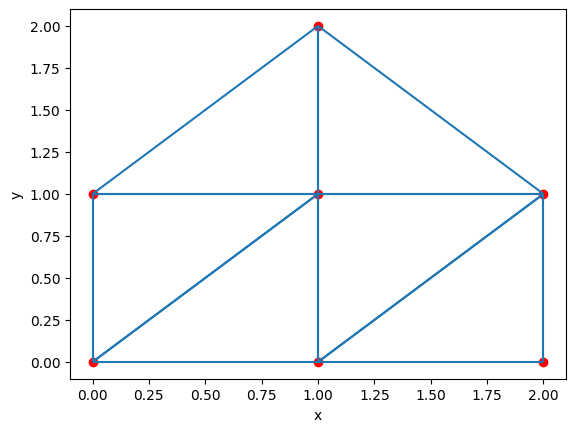

In [4]:
draw_mesh(points, triangles)

In [5]:
def load_mesh(file_path):
    with open(file_path, "r", encoding="utf-8") as f:
        n = int(f.readline().strip())
        m = int(f.readline().strip())

        points = []
        for _ in range(n):
            x, y = f.readline().split()
            points.append((float(x), float(y)))

        indices = []
        for _ in range(m):
            a, b, c = f.readline().split()
            indices.append((int(a), int(b), int(c)))

    return points, indices


In [6]:
points_siatka, triangles_siatka = load_mesh("siatka.txt")

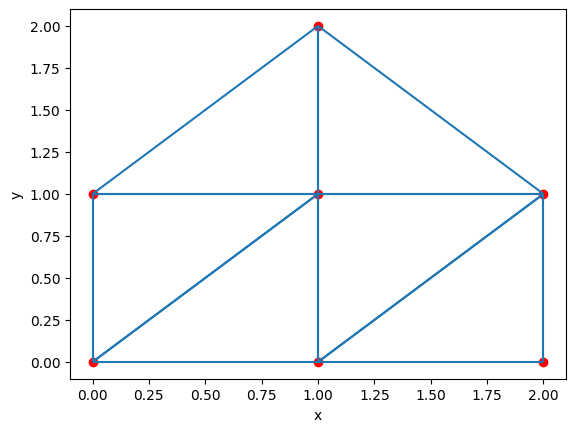

In [7]:
draw_mesh(points_siatka, triangles_siatka)

In [8]:
class HalfEdge:
    def __init__(self, origin : 'Vertex'=None, face : 'Face'=None, twin : 'HalfEdge'=None, next : 'HalfEdge'=None, prev : 'HalfEdge'=None):
        self.origin = origin

        self.face = face

        self.twin = twin

        self.next = next
        self.prev = prev

    def __eq__(self, other : 'HalfEdge'):
        return self.origin == other.origin and self.twin.origin == other.twin.origin

In [9]:
class Vertex:
    def __init__(self, position : tuple[float], halfedge : HalfEdge = None, id : int = None):
        self.position = position

        # halfedge: dowolna półkrawędź wychodząca z tego wierzchołka
        self.halfedge = halfedge

        # id: indeks wierzchołka
        self.id = id

    def __add__(self, other):
        return (self.position[0] + other.position[0], self.position[1] + other.position[1])

    def __sub__(self, other):
        return (self.position[0] - other.position[0], self.position[1] - other.position[1])

    def __mul__(self, num):
        return (self.position[0] * num, self.position[1] * num)

    def __eq__(self, other):
        return self.id == other.id

    def __hash__(self):
        return hash(self.id)

In [10]:
class Face:
    def __init__(self, halfedge : HalfEdge=None):
        # halfedge: dowolna półkrawędź należąca do tej ściany (trójkąta)
        self.halfedge = halfedge

In [11]:
class HalfEdgeDataStructure:
    def __init__(self, points, triangles):
        self.vertices = [Vertex(pos, id=i) for i, pos in enumerate(points)]
        self.triangles = list(triangles)

        self.faces = []
        self.half_edges = []
        self.half_edges_dict = {}  # (u, v) -> HalfEdge u->v

        self._build_structure()
        self._build_boundary()

    def _pair_halfedge(self, u, v, edge):
        # szukamy przeciwnej półkrawędzi v->u
        t = self.half_edges_dict.get((v, u))
        if t is not None:
            edge.twin = t
            t.twin = edge
            del self.half_edges_dict[(v, u)]
        else:
            self.half_edges_dict[(u, v)] = edge

    def _build_structure(self):
        for a, b, c in self.triangles:
            face = Face()

            edge_0 = HalfEdge(origin=self.vertices[a], face=face)
            edge_1 = HalfEdge(origin=self.vertices[b], face=face)
            edge_2 = HalfEdge(origin=self.vertices[c], face=face)

            edge_0.next, edge_1.next, edge_2.next = edge_1, edge_2, edge_0
            edge_0.prev, edge_1.prev, edge_2.prev = edge_2, edge_0, edge_1

            face.halfedge = edge_0

            if self.vertices[a].halfedge is None:
                self.vertices[a].halfedge = edge_0
            if self.vertices[b].halfedge is None:
                self.vertices[b].halfedge = edge_1
            if self.vertices[c].halfedge is None:
                self.vertices[c].halfedge = edge_2

            # łączenie bliźniaczych krawędzi/dodawanie krawędzi do mapy
            self._pair_halfedge(a, b, edge_0)
            self._pair_halfedge(b, c, edge_1)
            self._pair_halfedge(c, a, edge_2)

            self.faces.append(face)
            self.half_edges.extend([edge_0, edge_1, edge_2])

    def _build_boundary(self):
        twinless_half_edges = list(self.half_edges_dict.values())

        new_boundary = []
        # tworzenie krawędzi na brzegach i łączenie ich z bliźniaczymi
        for edge in twinless_half_edges:
            u = edge.origin.id
            v = edge.next.origin.id

            b = HalfEdge(origin=self.vertices[v], face = None)
            b.twin = edge
            edge.twin = b

            new_boundary.append(b)

        # stworzenie mapy kolejnych połączeń dla krawędzi zewnętrznych
        incoming = {}
        for edge in twinless_half_edges:
            v = edge.next.origin.id
            incoming[v] = edge

        # łączenie następnych krawędzi zewnętrznych w pętlę
        for edge in twinless_half_edges:
            b = edge.twin
            u = edge.origin.id
            prev = incoming.get(u)
            b_next = prev.twin
            b.next = b_next
            b_next.prev = b

        self.half_edges.extend(new_boundary)

In [12]:
halfEdgeStructure = HalfEdgeDataStructure(points, triangles)

In [13]:
import math

def visualize_halfedge_structure(mesh,
                                 draw_mesh_edges=True,
                                 draw_vertices=True,
                                 shrink=0.15,
                                 inward_offset=0.05):
    vis = Visualizer()

    def add(a, b): return (a[0] + b[0], a[1] + b[1])
    def sub(a, b): return (a[0] - b[0], a[1] - b[1])
    def mul(a, s): return (a[0] * s, a[1] * s)
    def dot(a, b): return a[0] * b[0] + a[1] * b[1]
    def length(v): return math.hypot(v[0], v[1])
    def norm(v):
        l = length(v)
        return (0.0, 0.0) if l == 0 else (v[0] / l, v[1] / l)

    # krawędzie triangulacji
    if draw_mesh_edges:
        verts_pos = [v.position for v in mesh.vertices]
        mesh_segments = []
        for a, b, c in mesh.triangles:
            mesh_segments.append((verts_pos[a], verts_pos[b]))
            mesh_segments.append((verts_pos[b], verts_pos[c]))
            mesh_segments.append((verts_pos[c], verts_pos[a]))
        vis.add_line_segment(mesh_segments)

    # wierzchołki
    if draw_vertices:
        vis.add_point([v.position for v in mesh.vertices], color='red')

    internal_segments, internal_tips = [], []
    boundary_segments, boundary_tips = [], []

    for he in mesh.half_edges:
        if he.next is None or he.origin is None:
            continue

        p0 = he.origin.position
        p1v = he.next.origin
        if p1v is None:
            continue
        p1 = p1v.position

        v = sub(p1, p0)
        L = length(v)
        if L == 0:
            continue

        # skrócenie odcinka
        start = add(p0, mul(v, shrink))
        end   = add(p0, mul(v, 1.0 - shrink))

        if he.face is None:
            # boundary: nie przesuwamy do wnętrza (bo nie ma ściany)
            boundary_segments.append((start, end))
            boundary_tips.append(end)
            continue

        # internal: przesuwamy do wnętrza trójkąta
        if he.prev is None:
            continue

        pa = he.origin.position
        pb = he.next.origin.position
        pc = he.prev.origin.position
        centroid = ((pa[0] + pb[0] + pc[0]) / 3.0, (pa[1] + pb[1] + pc[1]) / 3.0)

        n = norm((-v[1], v[0]))
        mid = ((p0[0] + p1[0]) / 2.0, (p0[1] + p1[1]) / 2.0)
        if dot(n, sub(centroid, mid)) < 0:
            n = (-n[0], -n[1])

        offset = inward_offset * L
        start_i = add(start, mul(n, offset))
        end_i   = add(end,   mul(n, offset))

        internal_segments.append((start_i, end_i))
        internal_tips.append(end_i)

    vis.add_line_segment(internal_segments)
    vis.add_point(internal_tips, color='blue')

    # boundary wyróżniamy kolorem końcówek
    vis.add_line_segment(boundary_segments)
    vis.add_point(boundary_tips, color='green')

    vis.show()


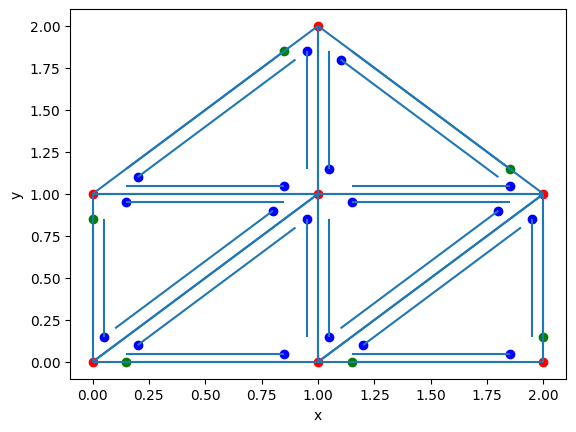

In [14]:
visualize_halfedge_structure(halfEdgeStructure)

In [58]:
big_mesh = load_mesh("big_siatka.txt")
big_mesh_structure = HalfEdgeDataStructure(big_mesh[0], big_mesh[1])

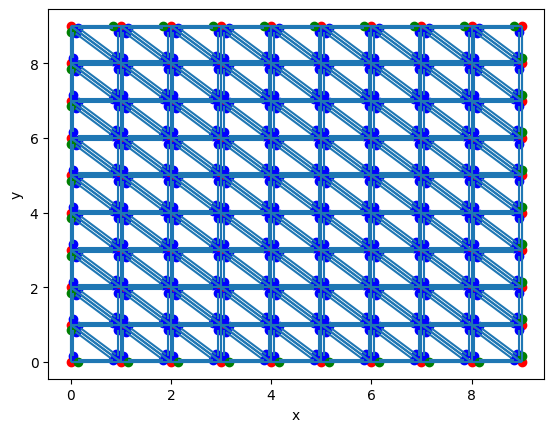

In [59]:
visualize_halfedge_structure(big_mesh_structure)

# Operacje na siatce trójkątnej
### 1. Wyznaczanie otoczenia dla wybranego wierzchołka
### 2. Wyznaczanie otoczenia dla wybranego trójkąta
### 3. Przeglądanie incydentnych trójkątów od wybranego trójkąta w kierunku wybranego punktu

## Operacje dla list

In [15]:
def visit_point(points, triangles, point_idx, vis):
    vertex = points[point_idx]
    vis.add_point(vertex, color='red')
    visited = set()
    for triangle in triangles:
        if point_idx in triangle:
            vis.add_point([points[idx] for idx in triangle], color='red')
            vis.add_line_segment((points[triangle[0]], points[triangle[1]]), color='red')
            vis.add_line_segment((points[triangle[1]], points[triangle[2]]), color='red')
            vis.add_line_segment((points[triangle[2]], points[triangle[0]]), color='red')
            visited.update(triangle)
    return vis, visited

In [60]:
def visualize_surrounding_points_list(points, triangles, vertex, layers=1):
    vis = Visualizer()
    vis.add_point(points)
    # Szukanie indeksu początkowego punktu
    point_idx = -1
    for idx, point in enumerate(points):
        if point == vertex:
            point_idx = idx
            break

    if point_idx == -1:
        raise Exception('No such point')

    # Odwiedzanie kolejnych warstw
    current_layer = {point_idx}
    all_visited = set()

    for _ in range(layers):
        next_layer = set()
        for idx in current_layer:
            if idx not in all_visited:
                vis, new_visited = visit_point(points, triangles, idx, vis)
                # Zbieramy punkty do kolejnej warstwy
                next_layer.update(new_visited)
                all_visited.add(idx)

        current_layer = next_layer - all_visited

    vis.add_point(vertex, color='green')

    vis.show()

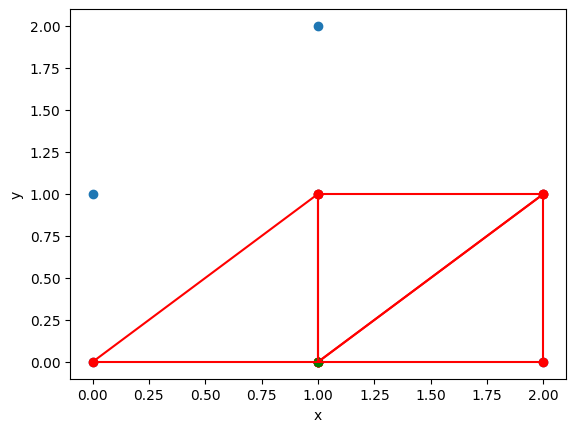

In [61]:
visualize_surrounding_points_list(points, triangles, (1, 0))

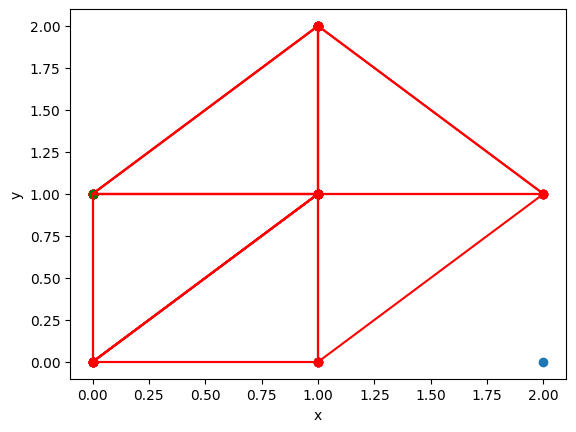

In [62]:
visualize_surrounding_points_list(points, triangles, (0, 1), 2)

In [70]:
def draw_triangle_list(vis : Visualizer, points, triangle):
    vis.add_point([points[idx] for idx in triangle], color='green')
    vis.add_line_segment((points[triangle[0]], points[triangle[1]]), color='green')
    vis.add_line_segment((points[triangle[1]], points[triangle[2]]), color='green')
    vis.add_line_segment((points[triangle[2]], points[triangle[0]]), color='green')

In [74]:
def visualize_surrounding_triangle_list(points, triangles, triangle, layers=1):
    vis = Visualizer()
    vis.add_point(points)

    if triangle not in triangles:
        raise Exception('No such triangle')

    # Odwiedzanie kolejnych warstw
    current_layer = set(triangle)
    all_visited = set()

    for _ in range(layers):
        next_layer = set()
        for idx in current_layer:
            if idx not in all_visited:
                vis, new_visited = visit_point(points, triangles, idx, vis)
                # Zbieramy punkty do kolejnej warstwy
                next_layer.update(new_visited)
                all_visited.add(idx)

        current_layer = next_layer - all_visited

    draw_triangle_list(vis, points, triangle)

    vis.show()

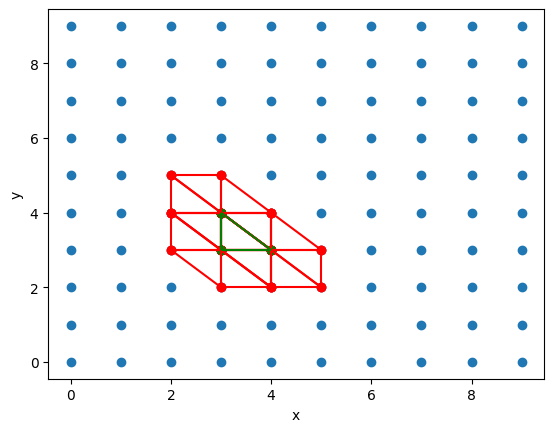

In [75]:
visualize_surrounding_triangle_list(big_mesh[0], big_mesh[1], big_mesh[1][60])

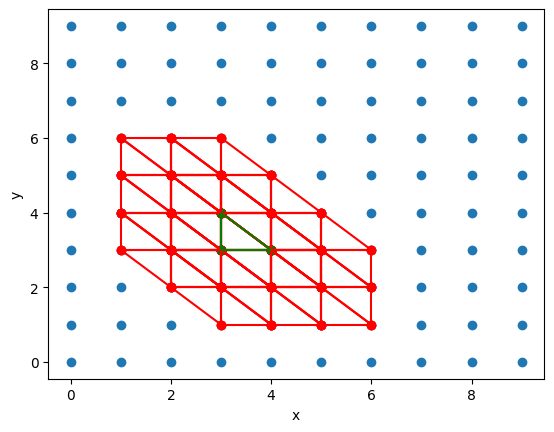

In [76]:
visualize_surrounding_triangle_list(big_mesh[0], big_mesh[1], big_mesh[1][60], 2)

## Operacje dla struktury Half Edge Data Structure

In [19]:
def visit_vertex(vertex: Vertex, vis: Visualizer):
    vis.add_point(vertex.position, color='red')
    visited = set()
    visited.add(vertex)

    curr_edge = vertex.halfedge
    # przechodzimy po wszystkich ścianach wokół punktu
    while curr_edge is not None:
        if curr_edge.face is not None:
            # Rysujemy wszystkie 3 boki trójkąta, do którego należy curr
            edge_in_face = curr_edge
            for _ in range(3):
                vis.add_line_segment((edge_in_face.origin.position, edge_in_face.next.origin.position), color='red')
                vis.add_point(edge_in_face.next.origin.position, color='red')
                visited.add(edge_in_face.next.origin)
                edge_in_face = edge_in_face.next

        # sprawdzamy, czy istnieje kolejna ściana
        curr_edge = curr_edge.twin.next if curr_edge.twin else None
        # sprawdziliśmy wszystko
        if curr_edge == vertex.halfedge:
            break

    return vis, visited

In [63]:
def visualize_surrounding_point_structure(structure: HalfEdgeDataStructure, vertex : Vertex, layers=1):
    vis = Visualizer()
    vis.add_point([point.position for point in structure.vertices])

    if vertex not in structure.vertices:
        raise Exception('No such vertex')

    # Odwiedzanie kolejnych warstw
    current_layer = {vertex}
    all_visited = set()

    for _ in range(layers):
        next_layer = set()
        for point in current_layer:
            if point not in all_visited:
                vis, new_visited = visit_vertex(point, vis)
                # Zbieramy punkty do kolejnej warstwy
                next_layer.update(new_visited)
                all_visited.add(point)

        current_layer = next_layer - all_visited

    vis.add_point(vertex.position, color='green')

    vis.show()

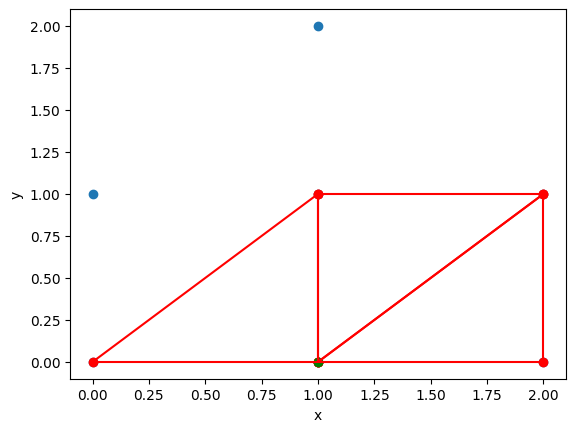

In [64]:
visualize_surrounding_point_structure(halfEdgeStructure, halfEdgeStructure.vertices[1])

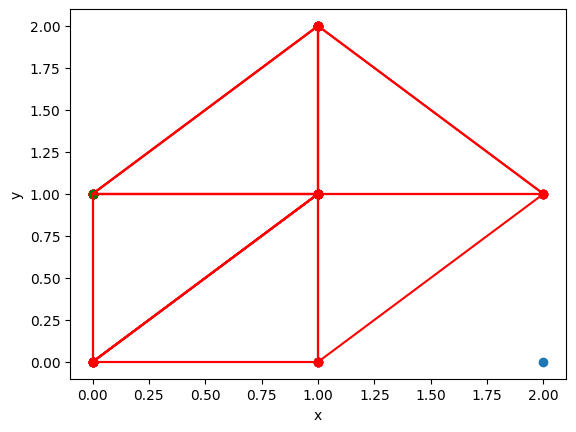

In [65]:
visualize_surrounding_point_structure(halfEdgeStructure, halfEdgeStructure.vertices[3], 2)

In [54]:
def draw_triangle_structure(face_points: list[Vertex | None], vis: Visualizer):
    vis.add_point([point.position for point in face_points], color='green')
    vis.add_line_segment((face_points[0].position, face_points[1].position), color='green')
    vis.add_line_segment((face_points[1].position, face_points[2].position), color='green')
    vis.add_line_segment((face_points[2].position, face_points[0].position), color='green')

In [66]:
def visualize_surrounding_triangle_structure(structure: HalfEdgeDataStructure, face : Face, layers=1):
    vis = Visualizer()
    vis.add_point([point.position for point in structure.vertices])

    if face not in structure.faces:
        raise Exception('No such face')

    edge_in_face = face.halfedge
    face_points = [edge_in_face.origin, edge_in_face.next.origin, edge_in_face.prev.origin]

    current_layer = set(face_points)
    all_visited = set()

    for _ in range(layers):
        next_layer = set()
        for point in current_layer:
            if point not in all_visited:
                vis, new_visited = visit_vertex(point, vis)
                # Zbieramy punkty do kolejnej warstwy
                next_layer.update(new_visited)
                all_visited.add(point)

        current_layer = next_layer - all_visited

    draw_triangle_structure(face_points, vis)

    vis.show()

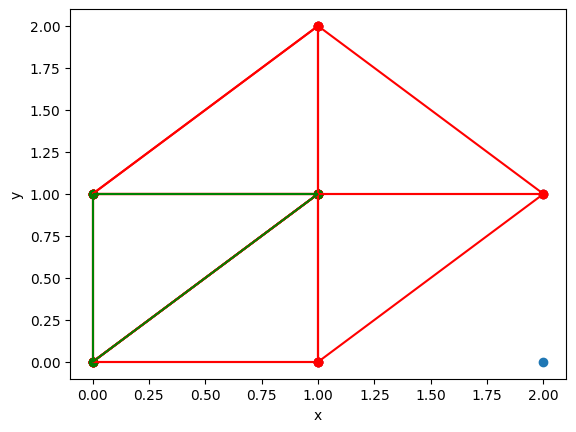

In [57]:
visualize_surrounding_triangle_structure(halfEdgeStructure, halfEdgeStructure.faces[1])

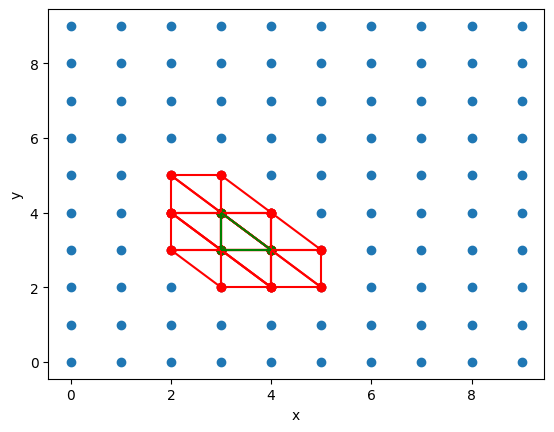

In [52]:
visualize_surrounding_triangle_structure(big_mesh_structure, big_mesh_structure.faces[60])

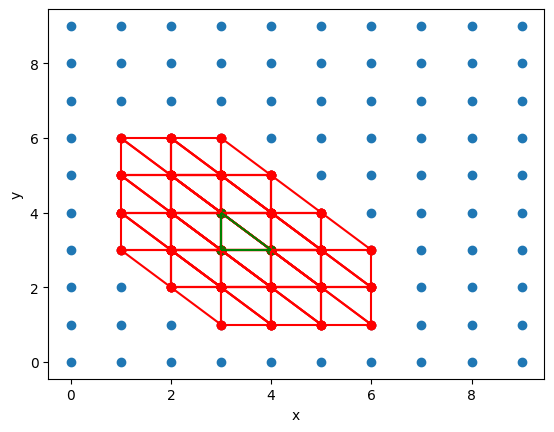

In [53]:
visualize_surrounding_triangle_structure(big_mesh_structure, big_mesh_structure.faces[60], 2)